⚡ Перед началом решения задачи выполните следующую ячейку - в ней скачиваются нужные файлы логов

In [2]:
!wget -O dataset.csv https://raw.githubusercontent.com/Tolstyakoff/Simulative_Stat/refs/heads/main/dataset.csv

--2026-01-25 06:32:19--  https://raw.githubusercontent.com/Tolstyakoff/Simulative_Stat/refs/heads/main/dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301517 (294K) [text/plain]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>] 294.45K  --.-KB/s    in 0.03s   

2026-01-25 06:32:19 (9.01 MB/s) - ‘dataset.csv’ saved [301517/301517]



**A. Описание и классификация переменных**

Загружаем данные из csv с детализацией типов данных

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import optimize

def comma_to_float(x):
    """Конвертирует строку с запятой в float"""
    try:
        if pd.isna(x) or str(x).strip() == '':
            return None
        # Убираем пробелы и заменяем запятую на точку
        return float(str(x).replace(',', '.'))
    except:
        return None

ecom = pd.read_csv(                 #Парсим данные, сразу в правильные типы
    'dataset.csv',
    sep=';',
    encoding='utf-8',
    parse_dates=['date'],           #Дата парсится отдельно
    dayfirst=True,
    dtype={                         #строки и целые типы
        'customer_id': 'Int64',     #Int64 (с возможностью пропуска данных)
        'age': 'Int64',
        'gender': 'str',
        'region': 'str',
        'traffic_source': 'str',
        'campaign': 'str',
        'pages_visited':'Int64',
        'converted':'Int64',
        'num_items': 'Int64',
        'delivery_time_days': 'Int64',
        'satisfaction': 'Int64'
        },
    converters={                    #десятичные числа, сначала конвртируем "," -> "."
        'purchase_amount': comma_to_float,
        'time_on_site_s': comma_to_float
    }
)


Конфигурация для графиков по каждой переменной, цвета + подписи

In [109]:
# Данные
data_list = [
    ecom['purchase_amount'],
    ecom['time_on_site_s'],
    ecom['pages_visited'],
    ecom['delivery_time_days'],
    ecom['satisfaction']
]

titles = ['Сумма покупки', 'Время на сайте', 'Посещенные страницы',
          'Время доставки', 'Удовлетворенность']
xlabels = ['Рубли', 'Секунды', 'Страницы', 'Дни', 'Баллы']
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lavender']

Строим гистограммы для ключевых переменных (*purchase_amount, time_on_site, pages_visited, delivery_time, satisfaction*)

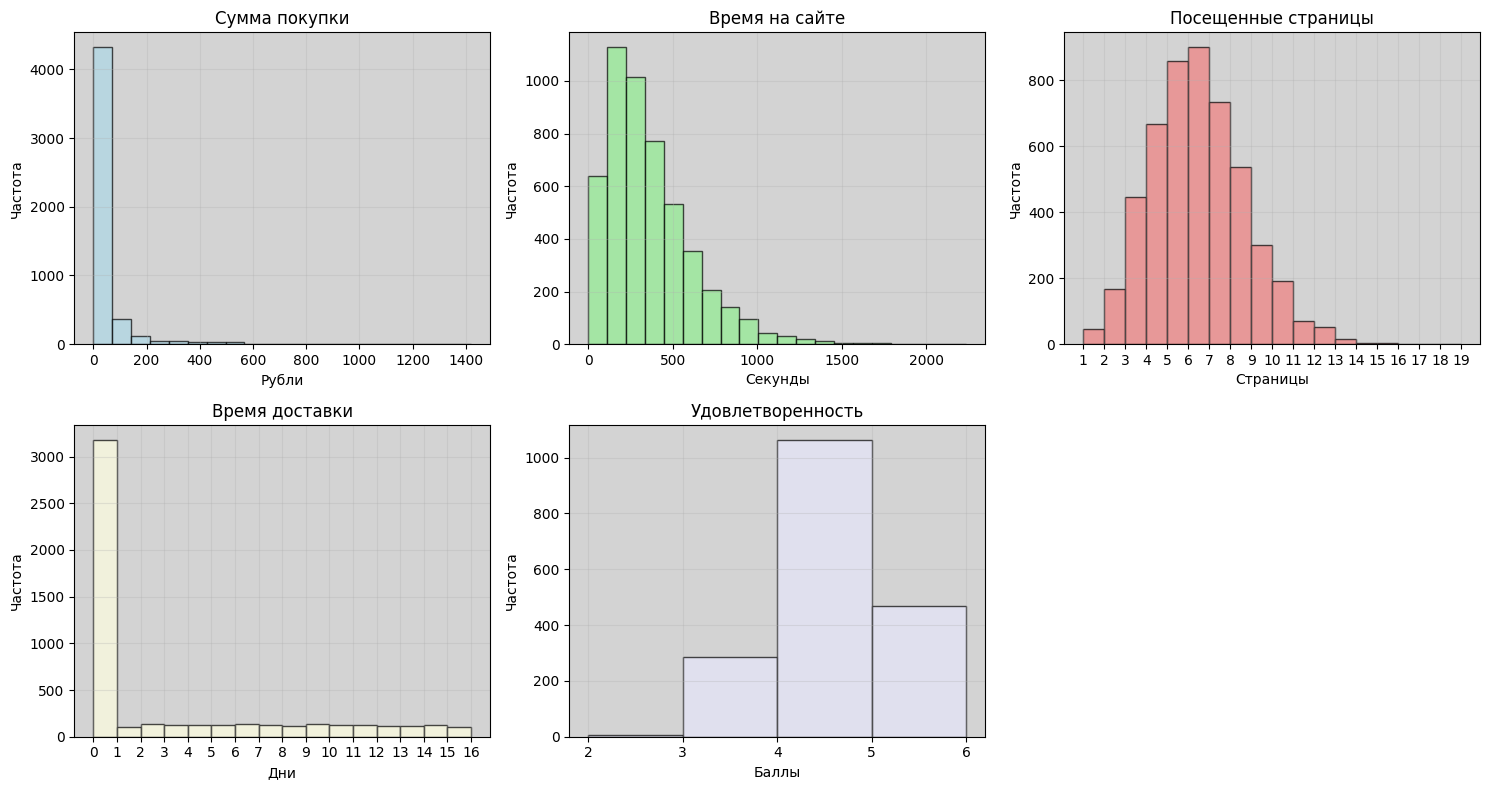

In [110]:
# Создаем графики
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='none')
axes_flat = axes.flatten()

for i in range(5):
    ax = axes_flat[i]
    ax.set_facecolor('lightgray')

    #настраиваем кодличсетво точек по оси ОХ для корректногоо отображения
    #целочисленных переменных с диапазорном меньше 20
    data_min = int(data_list[i].min())
    data_max = int(data_list[i].max())

    # Устанавливаем тики на оси X — целые значения от data_min до data_max
    if (data_max - data_min + 1) < 20:
      # Устанавливаем персональные бины и тики на оси X — от data_min до data_max
      bins_x = range(data_min, data_max+2)
      ax.set_xticks(range(data_min, data_max + 2))
    else:
      bins_x = 20

    # Простая гистограмма
    ax.hist(data_list[i].dropna(),
            color=colors[i],
            edgecolor='black',
            bins = bins_x, #выставлем бины
            alpha=0.7)

    ax.set_title(titles[i])
    ax.set_xlabel(xlabels[i])
    ax.set_ylabel('Частота')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}")) #Отбражение только целых значений

axes_flat[5].axis('off')
plt.tight_layout()
plt.show()

Построим ящики с усами (для себя). Фактически это аналог гистограммы

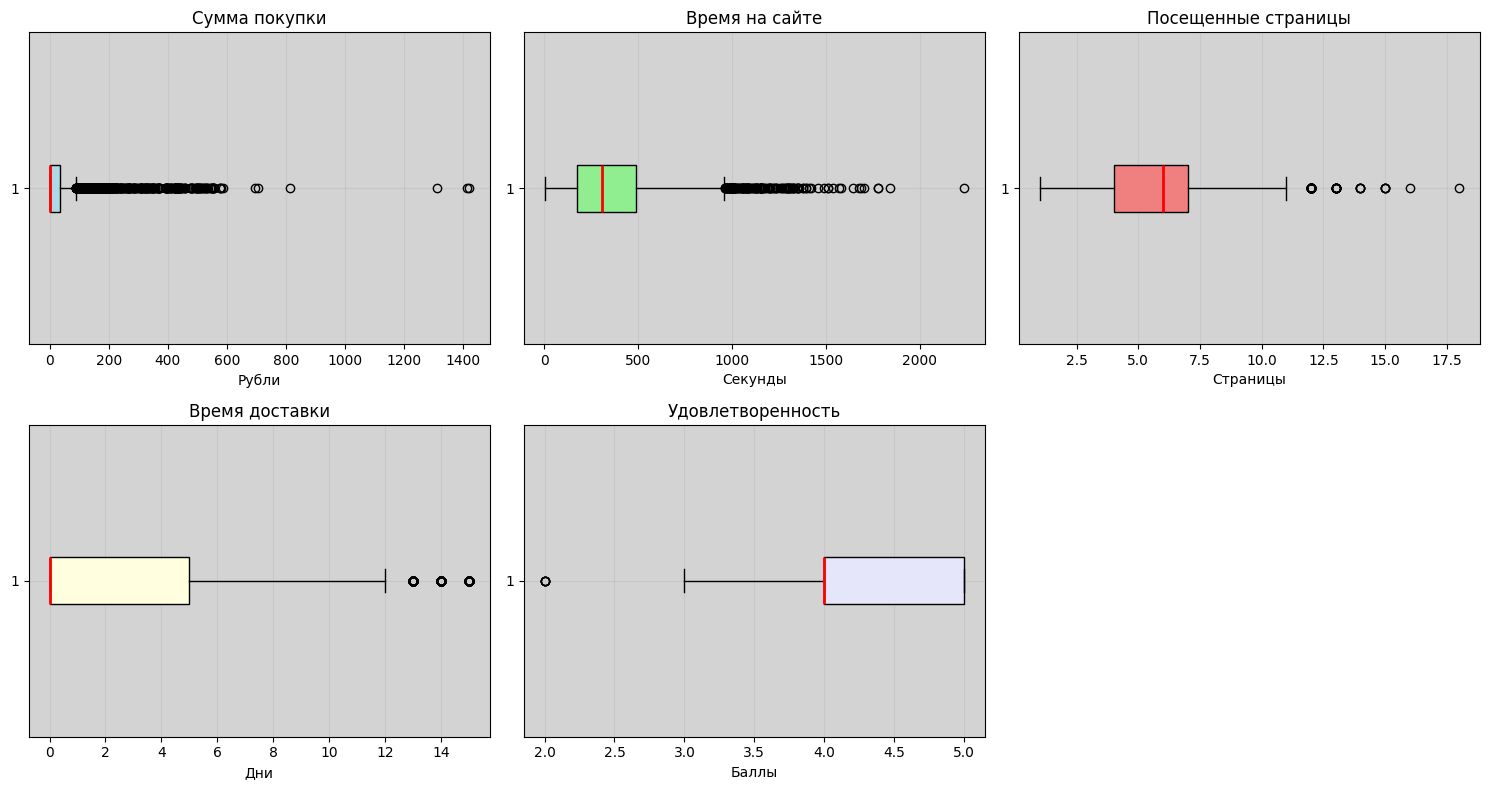

In [111]:
# Создаем графики
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='none')

# Преобразуем в плоский список
axes_flat = axes.flatten()

for i in range(5):
    ax = axes_flat[i]
    ax.set_facecolor('lightgray')
    # Boxplot
    ax.boxplot(data_list[i].dropna(),
               vert=False,
               patch_artist=True,
               boxprops=dict(facecolor=colors[i], color='black'),
               medianprops=dict(color='red', linewidth=2))

    # Настройки
    ax.set_title(titles[i])
    ax.set_xlabel(xlabels[i])
    ax.grid(True, alpha=0.3)

# Скрываем 6-й пустой график
axes_flat[5].axis('off')

plt.tight_layout()
plt.show()

Сводная статистика по ключевым переменным: среднее, медиана, дисперсия, коэффициент вариации.

In [112]:
# Столбцы для анализа
columns_to_analyze = ['purchase_amount', 'time_on_site_s',
                      'pages_visited', 'delivery_time_days', 'satisfaction']

# Функция для расчета статистик #############
# Использовать в будущем  ###################
def calculate_stats(series, zero_free=False):
    """
    Вычисляет базовые статистики для серии данных.
    Параметры:
    - series: pd.Series — входные данные;
    - zero_free: bool — если True, заменяет 0 на NaN перед расчётом.
    Возвращает:
    - pd.Series с показателями: Среднее, Медиана, Дисперсия, Коэф. вариации.
    """
    # Если zero_free=True, заменяем нули на NaN
    if zero_free:
        series = series.replace(0, np.nan)

    # Исключаем NaN (включая потенциально добавленные нули)
    data = series.dropna()

    if data.empty:
        return pd.Series([np.nan,np.nan, np.nan, np.nan,np.nan,np.nan],
                         index=['N','Среднее', 'Медиана', 'Дисперсия',
                                'Cтанд.отклонение', 'Коэф. вариации'])
    N = len(data)
    mean_val = data.mean()
    median_val = data.median()
    variance_val = data.var()
    std = data.std()
    cv_val = (std / mean_val) if mean_val != 0 else np.nan

    return pd.Series([N, mean_val, median_val, variance_val, std, cv_val],
                     index=['N','Среднее', 'Медиана', 'Дисперсия',
                            'Cтанд.отклонение','Коэф. вариации'])

#############################################

# Применяем функцию ко всем столбцам сразу
results = ecom[columns_to_analyze].apply(calculate_stats).T

# Форматирование в один проход
format_func = lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN'
formatted_results = results.copy()
formatted_results['Среднее'] = formatted_results['Среднее'].apply(format_func)
formatted_results['Медиана'] = formatted_results['Медиана'].apply(format_func)
formatted_results['Дисперсия'] = formatted_results['Дисперсия'].apply(format_func)
formatted_results['Коэф. вариации'] = (
    formatted_results['Коэф. вариации'].apply(
        lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN'
    )
)

print("Статистики:")
print("=" * 80)
print(formatted_results.to_string())
print("=" * 80)


Статистики:
                         N Среднее Медиана Дисперсия  Cтанд.отклонение Коэф. вариации
purchase_amount     5000.0   34.93    0.00   7615.05         87.264248           2.50
time_on_site_s      5000.0  361.87  305.45  65282.46        255.504323           0.71
pages_visited       5000.0    5.99    6.00      5.06          2.250262           0.38
delivery_time_days  5000.0    2.87    0.00     20.93          4.574751           1.59
satisfaction        1820.0    4.10    4.00      0.41          0.644064           0.16


In [113]:
#### Исключаем 0 из анализа
# Применяем функцию ко всем столбцам сразу
results = ecom[columns_to_analyze].apply(lambda s: calculate_stats(s, zero_free=True)).T

# Форматирование в один проход
format_func = lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN'
formatted_results = results.copy()
formatted_results['Среднее'] = formatted_results['Среднее'].apply(format_func)
formatted_results['Медиана'] = formatted_results['Медиана'].apply(format_func)
formatted_results['Дисперсия'] = formatted_results['Дисперсия'].apply(format_func)
formatted_results['Коэф. вариации'] = (
    formatted_results['Коэф. вариации'].apply(
        lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN'
    )
)

print("Статистики:")
print("=" * 80)
print(formatted_results.to_string())
print("=" * 80)


Статистики:
                         N Среднее Медиана Дисперсия  Cтанд.отклонение Коэф. вариации
purchase_amount     1820.0   95.96   52.88  15068.63        122.754336           1.28
time_on_site_s      5000.0  361.87  305.45  65282.46        255.504323           0.71
pages_visited       5000.0    5.99    6.00      5.06          2.250262           0.38
delivery_time_days  1820.0    7.89    8.00     17.91          4.231534           0.54
satisfaction        1820.0    4.10    4.00      0.41          0.644064           0.16


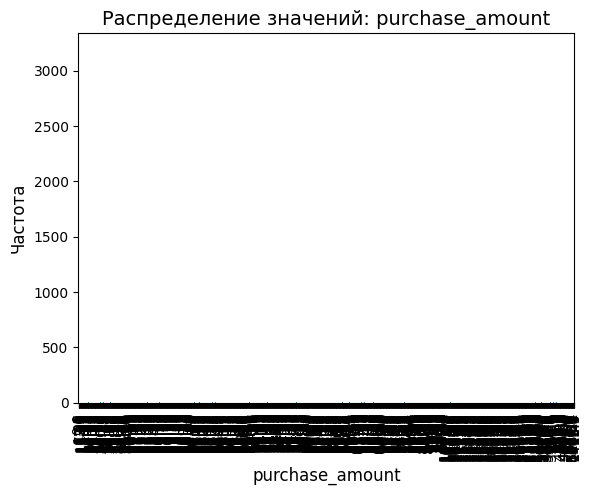

KeyboardInterrupt: 

In [ ]:
# А чё так можно было  что-ли ?
for x in columns_to_analyze:
    # Группируем по значению столбца, считаем количество наблюдений
    new_df = ecom.groupby(x, group_keys=False)[x].count()

    # Строим столбчатую диаграмму
    new_df.plot.bar()
    plt.title(f'Распределение значений: {x}', fontsize=14)
    plt.xlabel(x, fontsize=12)
    plt.ylabel('Частота', fontsize=12)

    plt.show()

# А нет, нельзя, лажа получается. Оставлю для истории :)

**B. Формирование выборок**

*   Получите три выборки по 800 наблюдений каждая: простая случайная, стратифицированная (по region) и систематическая (шаг = floor(N/800)).
*   Для каждой выборки рассчитайте среднее purchase_amount, стандартное отклонение, конверсию и медиану. Сравните с генеральной совокупностью.

In [162]:
# Формируем выборки
# Простая случайная выборки
simple_sample = ecom.sample(n=800, random_state=42)

# Стратифицированная выборка (по region)
from sklearn.model_selection import train_test_split

_, strat_sample = train_test_split(   #выгружаем в кортеж
    ecom,
    test_size=800,
    random_state=42,
    stratify=ecom['region']
)

# Систематическая выборка
N = len(ecom)
k = np.floor(N / 800).astype(int)
start_idx = np.random.randint(0, k)
systematic_sample = ecom.iloc[start_idx::k].head(800)

In [208]:
##Рассчет статистики по ГС
population = ecom['purchase_amount']
result = calculate_stats(population )

#Для конверсии исключим нулевые значения purchase_amount
result_client = calculate_stats(ecom['purchase_amount'],True )
conv = result_client['N'] /result['N']

#Рассчет статистики для проcтой случайной выборки
res_simple = calculate_stats(simple_sample['purchase_amount'] )
res_simple_client = calculate_stats(simple_sample['purchase_amount'], True )
conv_simple = res_simple_client['N'] / res_simple['N']

#Рассчет статистики для стратифицированной выборки
res_strat = calculate_stats(strat_sample['purchase_amount'] )
res_strat_client = calculate_stats(strat_sample['purchase_amount'], True )
conv_strat = res_strat_client['N'] / res_strat['N']

#Рассчет статистики для систематической выборки
res_systematic = calculate_stats(systematic_sample['purchase_amount'] )
res_systematic_client = calculate_stats(systematic_sample['purchase_amount'], True )
conv_systematic = res_systematic_client['N'] / res_systematic['N']

#Выыод данных
print (f"Генеральная совокупность\n\n{result.to_string()}")
print (f"Конверсия\t\t{conv:.2%}")
print ()

print (f"Простая случайная\n\n{res_simple.to_string()}")
print (f"Конверсия\t\t{conv_simple:.2%}")
print ()

print (f"Стратифитцированная\n\n{res_strat.to_string()}")
print (f"Конверсия\t\t{conv_strat:.2%}")
print ()

print (f"Систематизированная\n\n{res_systematic.to_string()}")
print (f"Конверсия\t\t{conv_systematic:.2%}")
print ()


Генеральная совокупность

N                   5000.000000
Среднее               34.927770
Медиана                0.000000
Дисперсия           7615.048930
Cтанд.отклонение      87.264248
Коэф. вариации         2.498420
Конверсия		36.40%

Простая случайная

N                    800.000000
Среднее               29.782212
Медиана                0.000000
Дисперсия           5408.669144
Cтанд.отклонение      73.543655
Коэф. вариации         2.469382
Конверсия		33.88%

Стратифитцированная

N                    800.000000
Среднее               30.265350
Медиана                0.000000
Дисперсия           5222.987748
Cтанд.отклонение      72.270241
Коэф. вариации         2.387887
Конверсия		36.25%

Систематизированная

N                    800.000000
Среднее               35.119763
Медиана                0.000000
Дисперсия           6735.688071
Cтанд.отклонение      82.071238
Коэф. вариации         2.336896
Конверсия		35.88%



**C. Количественная репрезентативность**

Для каждой выборки рассчитайте отклонение от генеральной (абсолютное и относительное) по purchase_amount.

In [167]:
#Решаем в лоб без циклов (пока)
dev_for =[]

# для Простая случайная
abs_dev =  abs(res_simple['Среднее'] - result ['Среднее'])
rel_dev = abs_dev /result ['Среднее']
dev_for.append(('простая случайная', abs_dev,rel_dev) )

# для Стратифитцированная
abs_dev =  abs(res_strat['Среднее'] - result ['Среднее'])
rel_dev = abs_dev /result ['Среднее']
dev_for.append(('стратифитцированная', abs_dev,rel_dev) )

# для Систематизированная
abs_dev =  abs(res_systematic['Среднее'] - result ['Среднее'])
rel_dev = abs_dev /result ['Среднее']
dev_for.append(('систематизированная', abs_dev,rel_dev) )

min_element = min(dev_for, key=lambda x: x[2])  #прикольная фича
print(f"Наиболее репрезентативна {min_element[0]} выборка")

Наиболее репрезентативна систематизированная выборка


**D. Доверительные интервалы**

Постройте 95% доверительный интервал для среднего purchase_amount (общий) и для среднего для каждой выборки.
Постройте доверительные интервалы для конверсии.
Интерпретируйте результаты.

In [209]:
# 95% доверительный интервал
dov_interv = []

#ГC
n = result ['N']
mean_val = result ['Среднее']
std_val = result ['Cтанд.отклонение']  # несмещенная оценка

dov_interv.append(('ген. совокупность', n, mean_val,std_val) )

# для Простая случайная
n = res_simple ['N']
mean_val = res_simple ['Среднее']
std_val = res_simple ['Cтанд.отклонение']

dov_interv.append(('простая случайная', n, mean_val,std_val) )
# для Стратифитцированная
n = res_strat ['N']
mean_val = res_strat ['Среднее']
std_val = res_strat ['Cтанд.отклонение']

dov_interv.append(('стратифицированная', n, mean_val,std_val) )
# для Систематизированная
n = res_systematic ['N']
mean_val = res_systematic ['Среднее']
std_val = res_systematic ['Cтанд.отклонение']

dov_interv.append(('систематизированная', n, mean_val,std_val) )

# прогоним в цикле для всех ( а ведь было проще написать одну функцию,
# чтобы закинуть тудв пандас и на выходе интервал, но уже сделал)
print(f"95% доверительный интервал для среднего:")
for item in dov_interv:
    s = item[0]           # строка
    n = int(item[1])     # преобразуем np.float64 в обычный float
    mean_val = float(item[2])
    std_val = float(item[3])

    alpha = 0.05
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    margin_of_error = t_critical * (std_val / np.sqrt(n))

    ci_lower = mean_val - margin_of_error
    ci_upper = mean_val + margin_of_error
    l= ci_upper - ci_lower
    print(f"для выборки - {s}: \t({ci_lower:.2f}, {ci_upper:.2f})\t дина интервала: {l:.4}")

95% доверительный интервал для среднего:
для выборки - ген. совокупность: 	(32.51, 37.35)	 дина интервала: 4.839
для выборки - простая случайная: 	(24.68, 34.89)	 дина интервала: 10.21
для выборки - стратифицированная: 	(25.25, 35.28)	 дина интервала: 10.03
для выборки - систематизированная: 	(29.42, 40.82)	 дина интервала: 11.39


In [227]:
#Для конверсии из лекции
from math import sqrt

n = len(population)
m = (population > 0).sum()

p_hat = m / n             # Рассчитать выборочную долю
q_hat  = 1 - p_hat

z = 1.96                  #Для ДИ 95% z ≈ 1.96 (из таблицы)

se = sqrt((p_hat * q_hat) / n)  # Стандартная ошибка

ci_lower = p_hat - z * se  # Нижняя граница ДИ
ci_upper = p_hat + z * se  # Верхняя граница ДИ

print(f"для генеральной совокупности: \t({ci_lower:.2f}, {ci_upper:.2f})\t дина интервала: {l:.4}")



для генеральной совокупности: 	(0.35, 0.38)	 дина интервала: 0.002267


In [228]:
#Для конверсии через ЦПТ
n_iterations = 1000
sample_size = 800

conversion = pd.Series([
    (population.sample(n=sample_size, replace=True) > 0).mean()
    for _ in range(n_iterations)
])

#Повторяем что было, хотя можно было это сделать сразу и загнать в цикл выше
conv_res = calculate_stats(conversion)

n = conv_res ['N']
mean_val = conv_res ['Среднее']
std_val = conv_res ['Cтанд.отклонение']
s = 'Конверсия'

alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
margin_of_error = t_critical * (std_val / np.sqrt(n))

ci_lower = mean_val - margin_of_error
ci_upper = mean_val + margin_of_error
l= ci_upper - ci_lower
print(f"для выборки - {s}: \t({ci_lower:.2f}, {ci_upper:.2f})\t дина интервала: {l:.4}")

**E. ЦПТ и Закон больших чисел**

Из генеральной совокупности многократно (1000 раз) взять подвыборки размера n = 5, 30, 100; для каждой серии построить распределение средних и показать графически с гистограммами и Q-Q плотом.

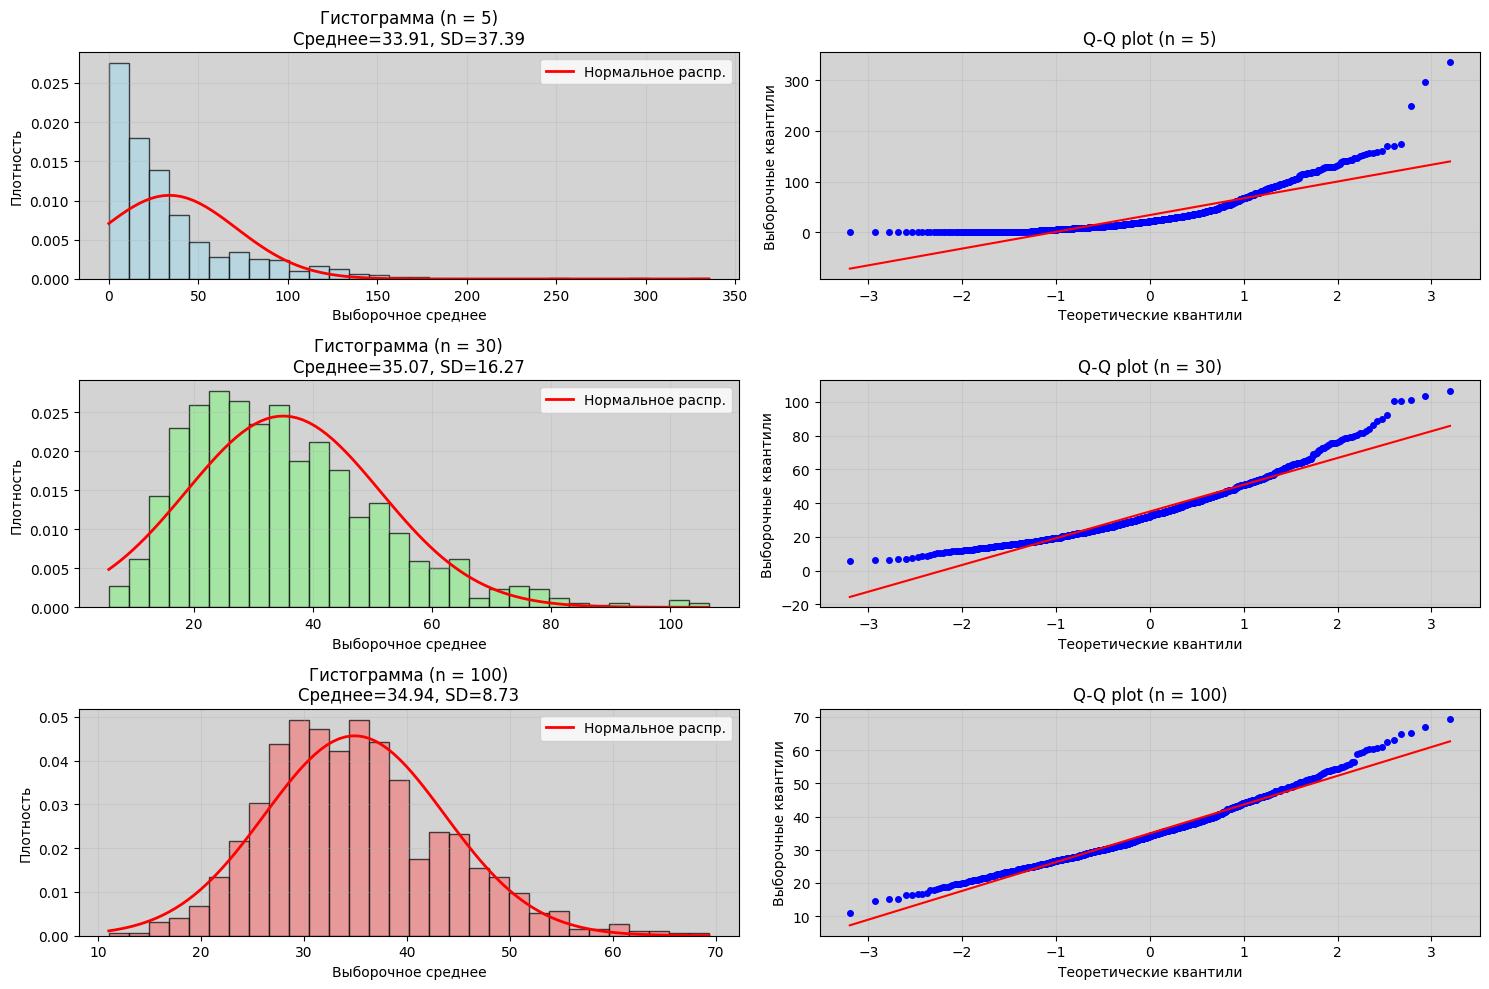

In [222]:
# Данные
# population = ecom['purchase_amount'] - определена выше
sample_sizes = [5, 30, 100]
n_iterations = 1000
colors = ['lightblue', 'lightgreen', 'lightcoral']

# Создаем графики
fig, axes = plt.subplots(3, 2, figsize=(15, 10), facecolor='none')
axes = axes.flatten()

variances = [] # для дисперсии

for idx, n in enumerate(sample_sizes):
    # Сбор средних
    sample_means = []
    for _ in range(n_iterations):
        sample = np.random.choice(population, size=n, replace=True)
        sample_means.append(np.mean(sample))

    sample_means = np.array(sample_means) #массив средних
    variances.append(sample_means.var())  #дисперсия

    # Гистограмма (левый столбец)
    ax_hist = axes[idx*2]
    ax_hist.set_facecolor('lightgray')

    # Настройка бинов и тиков для целых значений если диапазон маленький как в части А
    data_min = int(sample_means.min())
    data_max = int(sample_means.max())

    if (data_max - data_min + 1) < 30:
        bins_x = range(data_min, data_max+2)
        ax_hist.set_xticks(range(data_min, data_max + 2))
    else:
        bins_x = 30

    ax_hist.hist(sample_means,
                 bins=bins_x,
                 color=colors[idx],
                 edgecolor='black',
                 alpha=0.7,
                 density=True)

    # Теоретическая нормальная кривая
    x = np.linspace(sample_means.min(), sample_means.max(), 100)
    normal_pdf = stats.norm.pdf(x, loc=sample_means.mean(), scale=sample_means.std())
    ax_hist.plot(x, normal_pdf, 'r-', linewidth=2, label='Нормальное распр.')

    ax_hist.set_title(f'Гистограмма (n = {n})\nСреднее={sample_means.mean():.2f}, SD={sample_means.std():.2f}')
    ax_hist.set_xlabel('Выборочное среднее')
    ax_hist.set_ylabel('Плотность')
    ax_hist.grid(True, alpha=0.3)
    ax_hist.legend()

    # Q-Q plot (правый столбец)
    ax_qq = axes[idx*2 + 1]
    ax_qq.set_facecolor('lightgray')
    stats.probplot(sample_means, dist="norm", plot=ax_qq)

    # Стилизация Q-Q plot
    ax_qq.get_lines()[0].set_markersize(4)
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.set_title(f'Q-Q plot (n = {n})')
    ax_qq.set_xlabel('Теоретические квантили')
    ax_qq.set_ylabel('Выборочные квантили')
    ax_qq.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Показать, как меняется дисперсия средних при росте n (визуально и численно).

При n: 5	 дисперсия: 1473.505
При n: 30	 дисперсия: 265.794
При n: 100	 дисперсия: 72.967


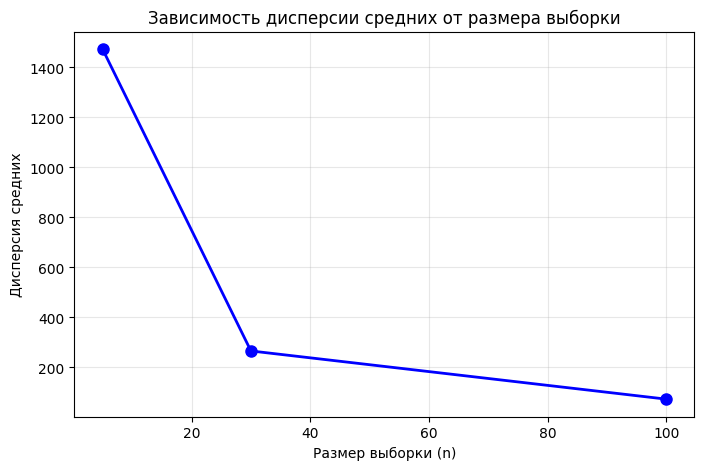

In [117]:
for idx, n in enumerate(sample_sizes):
  print(f"При n: {n}\t дисперсия: {variances[idx]:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, variances, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Размер выборки (n)')
plt.ylabel('Дисперсия средних')
plt.title('Зависимость дисперсии средних от размера выборки')
plt.grid(True, alpha=0.3)
plt.show()

**F. Параметрические оценки**
Для purchase_amount (среди покупателей) попытаться подобрать распределение (лог-нормальное, гамма и т.п.). Оцените параметры методом максимального правдоподобия или методом моментов.

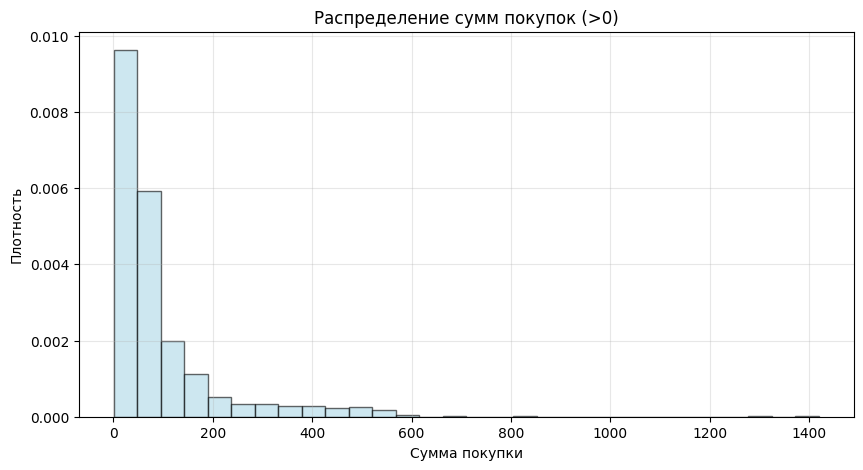

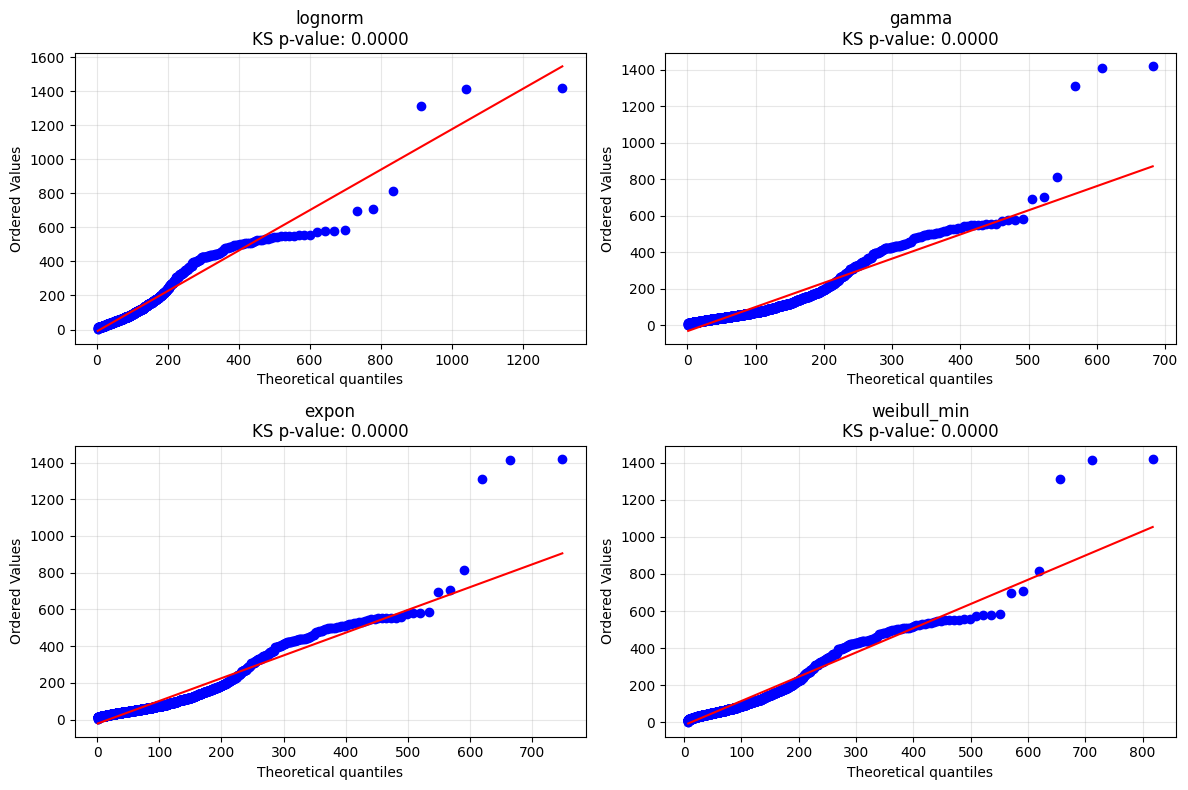


Результаты подгонки распределений:
  distribution  ks_pvalue         aic
0      lognorm        0.0  19724.4445
1        gamma        0.0  20195.2582
2        expon        0.0  20215.7187
3  weibull_min        0.0         inf


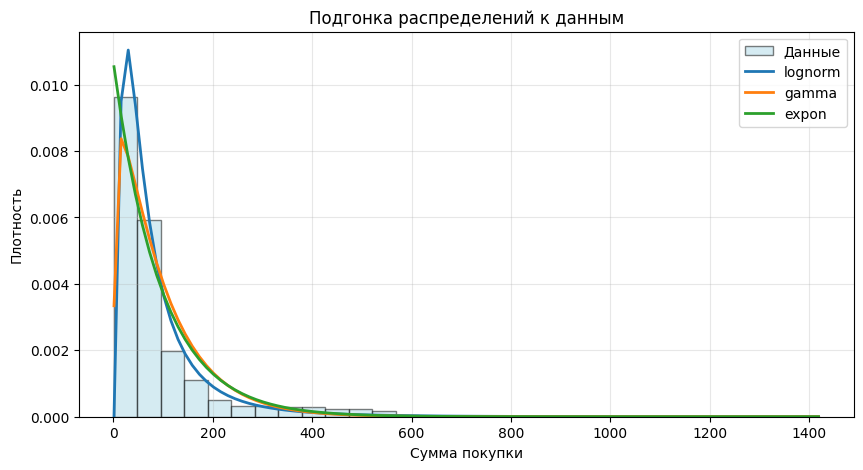

In [118]:
# Данные (только покупки > 0)
data = ecom[ecom['purchase_amount'] > 0]['purchase_amount'].values

# Гистограмма данных
plt.figure(figsize=(10, 5))

plt.hist( data,
          bins=30,
          density=True,
          alpha=0.6,
          color='lightblue',
          edgecolor='black')

plt.xlabel('Сумма покупки')
plt.ylabel('Плотность')
plt.title('Распределение сумм покупок (>0)')
plt.grid(alpha=0.3)
plt.show()

# Попробуем подогнать распределения
distributions = [
    ('lognorm', stats.lognorm),       #Лог нормальное
    ('gamma', stats.gamma),           #Гамма
    ('expon', stats.expon),           #Экспоненциальное распределение
    ('weibull_min', stats.weibull_min)#Распределение Вейбулла
]

# Подгонка методом максимального правдоподобия
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

results = []
for idx, (dist_name, dist) in enumerate(distributions):
    ax = axes[idx]

    params = dist.fit(data)
    fitted_dist = dist(*params)

    # QQ-plot для проверки
    stats.probplot(data, dist=fitted_dist, plot=ax)

    # Тест Колмогорова-Смирнова
    ks_stat, ks_pvalue = stats.kstest(data, fitted_dist.cdf)

    results.append({
        'distribution': dist_name,
        'params': params,
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_pvalue,
         'aic': 2 * len(params) - 2 * fitted_dist.logpdf(data).sum()
        })

    ax.set_title(f'{dist_name}\nKS p-value: {ks_pvalue:.4f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Результаты в таблице
results_df = pd.DataFrame(results)
print("\nРезультаты подгонки распределений:")
print(results_df[['distribution', 'ks_pvalue', 'aic']].round(4))

# Визуализация лучшего распределения
plt.figure(figsize=(10, 5))
x = np.linspace(data.min(), data.max(), 100)

# Гистограмма данных
plt.hist(data, bins=30, density=True, alpha=0.5, label='Данные', color='lightblue', edgecolor='black')

# Подогнанные распределения
for dist_name, dist in distributions[:3]:  # первые три
    params = dist.fit(data)
    fitted_dist = dist(*params)
    plt.plot(x, fitted_dist.pdf(x), label=dist_name, linewidth=2)

plt.xlabel('Сумма покупки')
plt.ylabel('Плотность')
plt.title('Подгонка распределений к данным')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [102]:
len(result)

6

**G. Свойства оценок и обсуждение**
Для оценки среднего purchase_amount сравните оценки по смещённости и состоятельности (можно проверить моделированием: берем несколько случайных выборок разного размера (10, 50, 200) и считаем среднее. Далее вычитаем среднее ГС и выборок – делаем вывод)

In [126]:
#Возьмем по аналогиии с задачей E

sample_sizes = [10, 30, 50, 100, 200]  #переопределим массив
samples = {}

stats_all = [] #спсиок из пандас датафреймов для хранения статистк выборок

result  = calculate_stats(ecom['purchase_amount'],True)
# Создаем 5 выборок разных размеров
for size in sample_sizes:
      key = f'sample_{size}'
      samples[key] = np.random.choice(data, size=size, replace=True)
      stats_all.append(calculate_stats(pd.Series(samples[key]),False ) )
'''

# Создаем 5 выборок разных размеров
for size in sample_sizes:
      key = f'sample_{size}'
      samples[key] = np.random.choice(population, size=size, replace=True)
      stats_all.append(calculate_stats(pd.Series(samples[key]),False ) )
'''
# Инициализируем переменные для оценки расхождений
counters = {
    'mean': {'inc': 0, 'dec': 0},
    'variance': {'inc': 0, 'dec': 0},
    'std': {'inc': 0, 'dec': 0}
}

prev_deviations = {'mean': None, 'variance': None, 'std': None}
all_deviations = [] #величина отклонений

# Основной цикл
for i,stats in enumerate(stats_all):
    # Текущие отклонения
    deviations = {
        'sample_size': sample_sizes[i],
        'mean': stats['Среднее'] - result['Среднее'],
        'variance': stats['Дисперсия'] - result['Дисперсия'],
        'std': stats['Cтанд.отклонение'] - result['Cтанд.отклонение']
    }
    all_deviations.append(deviations)

    # Проверяем каждую метрику
    for metric in ['mean', 'variance', 'std']:
        if prev_deviations[metric] is not None:

           current_abs = abs(deviations[metric])
           prev_abs = abs(prev_deviations[metric])

           if current_abs > prev_abs:
                counters[metric]['inc'] += 1
           elif current_abs < prev_abs:
                counters[metric]['dec'] += 1

    # Обновляем предыдущие значения
    prev_deviations = deviations

# Выводим результаты
print("Среднее: возрастающих =", counters['mean']['inc'], "убывающих =", counters['mean']['dec'])
print("Дисперсия: возрастающих =", counters['variance']['inc'], "убывающих =", counters['variance']['dec'])
print("Стандартное отклонение: возрастающих =", counters['std']['inc'], "убывающих =", counters['std']['dec'])




Среднее: возрастающих = 1 убывающих = 3
Дисперсия: возрастающих = 1 убывающих = 3
Стандартное отклонение: возрастающих = 1 убывающих = 3


In [130]:
len(data)

1820

Визуализация *(код сгенерирован ИИ)*


СВОДНАЯ ИНФОРМАЦИЯ ОБ ОТКЛОНЕНИЯХ:
Выборка         Среднее    Абс.откл.    Отн.откл.%   Дисперсия    Абс.откл.    Отн.откл.%   Ст.откл.     Абс.откл.    Отн.откл.%  
--------------------------------------------------------------------------------------------------------------------------------------------
Выборка 10      75.82      20.13        21.0         6246.83      8821.79      58.5         79.04        43.72        35.6        
Выборка 30      85.57      10.39        10.8         9711.37      5357.26      35.6         98.55        24.21        19.7        
Выборка 50      100.73     4.77         5.0          13534.57     1534.06      10.2         116.34       6.42         5.2         
Выборка 100     99.58      3.63         3.8          28547.49     13478.87     89.4         168.96       46.21        37.6        
Выборка 200     81.05      14.90        15.5         8535.69      6532.93      43.4         92.39        30.37        24.7        
Ген.совок.      95.96      -         

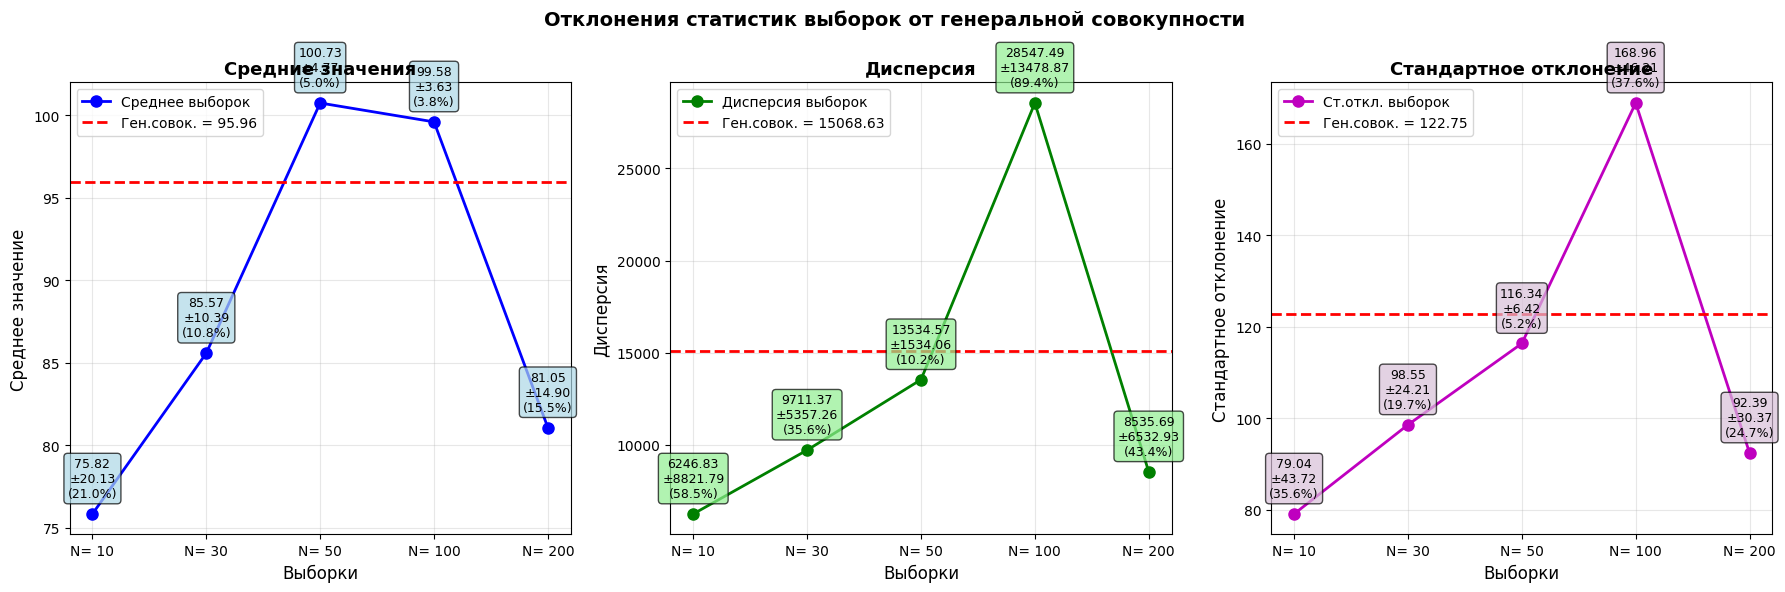

In [127]:
# Создаем три графика в одном окне
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Отклонения статистик выборок от генеральной совокупности', fontsize=14, fontweight='bold')

# Данные для графиков
x_positions = np.arange(len(sample_sizes))
x_labels = [f'N= {size}' for size in sample_sizes]

# 1. График для среднего
ax1 = axes[0]

# Значения среднего для выборок
sample_means = [stats['Среднее'] for stats in stats_all]

# Линия для средних значений выборок
ax1.plot(x_positions, sample_means, 'bo-', linewidth=2, markersize=8, label='Среднее выборок')

# Горизонтальная линия для результата
result_mean = result['Среднее']
ax1.axhline(y=result_mean, color='r', linestyle='--', linewidth=2, label=f'Ген.совок. = {result_mean:.2f}')

# Аннотации для каждой точки
for i, (x, sample_mean) in enumerate(zip(x_positions, sample_means)):
    # Абсолютное отклонение
    abs_dev = abs(sample_mean - result_mean)
    # Относительное отклонение в процентах
    rel_dev = (abs_dev / result_mean * 100) if result_mean != 0 else 0

    # Текст аннотации
    annotation_text = f'{sample_mean:.2f}\n±{abs_dev:.2f}\n({rel_dev:.1f}%)'

    # Добавляем аннотацию
    ax1.annotate(annotation_text,
                 xy=(x, sample_mean),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

# Настройки графика 1
ax1.set_xlabel('Выборки', fontsize=12)
ax1.set_ylabel('Среднее значение', fontsize=12)
ax1.set_title('Средние значения', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(x_labels, rotation=0)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. График для дисперсии
ax2 = axes[1]

# Значения дисперсии для выборок
sample_variances = [stats['Дисперсия'] for stats in stats_all]

# Линия для дисперсии выборок
ax2.plot(x_positions, sample_variances, 'go-', linewidth=2, markersize=8, label='Дисперсия выборок')

# Горизонтальная линия для результата
result_variance = result['Дисперсия']
ax2.axhline(y=result_variance, color='r', linestyle='--', linewidth=2, label=f'Ген.совок. = {result_variance:.2f}')

# Аннотации для каждой точки
for i, (x, sample_var) in enumerate(zip(x_positions, sample_variances)):
    # Абсолютное отклонение
    abs_dev = abs(sample_var - result_variance)
    # Относительное отклонение в процентах
    rel_dev = (abs_dev / result_variance * 100) if result_variance != 0 else 0

    # Текст аннотации
    annotation_text = f'{sample_var:.2f}\n±{abs_dev:.2f}\n({rel_dev:.1f}%)'

    # Добавляем аннотацию
    ax2.annotate(annotation_text,
                 xy=(x, sample_var),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Настройки графика 2
ax2.set_xlabel('Выборки', fontsize=12)
ax2.set_ylabel('Дисперсия', fontsize=12)
ax2.set_title('Дисперсия', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(x_labels, rotation=0)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. График для стандартного отклонения
ax3 = axes[2]

# Значения стандартного отклонения для выборок
sample_stds = [stats['Cтанд.отклонение'] for stats in stats_all]

# Линия для стандартного отклонения выборок
ax3.plot(x_positions, sample_stds, 'mo-', linewidth=2, markersize=8, label='Ст.откл. выборок')

# Горизонтальная линия для результата
result_std = result['Cтанд.отклонение']
ax3.axhline(y=result_std, color='r', linestyle='--', linewidth=2, label=f'Ген.совок. = {result_std:.2f}')

# Аннотации для каждой точки
for i, (x, sample_std) in enumerate(zip(x_positions, sample_stds)):
    # Абсолютное отклонение
    abs_dev = abs(sample_std - result_std)
    # Относительное отклонение в процентах
    rel_dev = (abs_dev / result_std * 100) if result_std != 0 else 0

    # Текст аннотации
    annotation_text = f'{sample_std:.2f}\n±{abs_dev:.2f}\n({rel_dev:.1f}%)'

    # Добавляем аннотацию
    ax3.annotate(annotation_text,
                 xy=(x, sample_std),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='thistle', alpha=0.7))

# Настройки графика 3
ax3.set_xlabel('Выборки', fontsize=12)
ax3.set_ylabel('Стандартное отклонение', fontsize=12)
ax3.set_title('Стандартное отклонение', fontsize=13, fontweight='bold')
ax3.set_xticks(x_positions)
ax3.set_xticklabels(x_labels, rotation=0)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Настраиваем отступы
plt.tight_layout()

# Выводим общую информацию
print("\n" + "="*80)
print("СВОДНАЯ ИНФОРМАЦИЯ ОБ ОТКЛОНЕНИЯХ:")
print("="*80)
print(f"{'Выборка':<15} {'Среднее':<10} {'Абс.откл.':<12} {'Отн.откл.%':<12} {'Дисперсия':<12} {'Абс.откл.':<12} {'Отн.откл.%':<12} {'Ст.откл.':<12} {'Абс.откл.':<12} {'Отн.откл.%':<12}")
print("-"*140)

for i, size in enumerate(sample_sizes):
    mean = sample_means[i]
    var = sample_variances[i]
    std = sample_stds[i]

    mean_abs = abs(mean - result_mean)
    mean_rel = (mean_abs / result_mean * 100) if result_mean != 0 else 0

    var_abs = abs(var - result_variance)
    var_rel = (var_abs / result_variance * 100) if result_variance != 0 else 0

    std_abs = abs(std - result_std)
    std_rel = (std_abs / result_std * 100) if result_std != 0 else 0

    print(f"{f'Выборка {size}':<15} {mean:<10.2f} {mean_abs:<12.2f} {mean_rel:<12.1f} {var:<12.2f} {var_abs:<12.2f} {var_rel:<12.1f} {std:<12.2f} {std_abs:<12.2f} {std_rel:<12.1f}")

print("="*140)
print(f"{'Ген.совок.':<15} {result_mean:<10.2f} {'-':<12} {'-':<12} {result_variance:<12.2f} {'-':<12} {'-':<12} {result_std:<12.2f} {'-':<12} {'-':<12}")
print("="*140)

plt.show()


,0
N,5000.000000
Среднее,34.927770
Медиана,0.000000
Дисперсия,7615.048930
Cтанд.отклонение,87.264248
Коэф. вариации,2.498420
